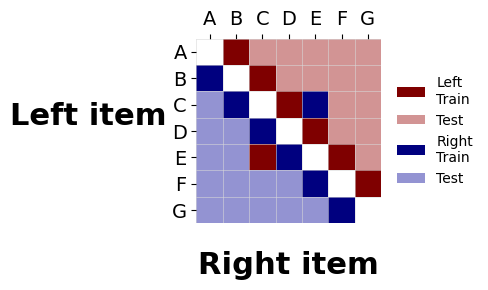

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Items and base condition matrix
# ------------------------------------------------------------
items = list("ABCDEFG")          # A … G
n = len(items)

cond = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            cond[i, j] = "diag"
        elif j > i:
            cond[i, j] = "left-train"  if j == i + 1 else "left-test"
        else:
            cond[i, j] = "right-train" if i == j + 1 else "right-test"

# ------------------------------------------------------------
# 2. Violation overrides  ------------------------------------
#    Pair(s) given as (left_item, right_item, new_label)
# ------------------------------------------------------------
violations = [
    ("C", "E", "right-train"),  # solid blue
    ("E", "C", "left-train"),   # solid red
]

for left, right, new_label in violations:
    i = items.index(left)
    j = items.index(right)
    cond[i, j] = new_label

# ------------------------------------------------------------
# 3. Colour palette
# ------------------------------------------------------------
palette = {
    "left-train"  : "#7f0000",   # dark red
    "left-test"   : "#d29494",   # light red
    "right-train" : "#00007f",   # dark blue
    "right-test"  : "#9393d2",   # light blue
    "diag"        : "white",
}

# ------------------------------------------------------------
# 4. Plot (Option 2: single faint grid)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

# 4-a  coloured squares (no edges)
for (i, j), label in np.ndenumerate(cond):
    ax.add_patch(
        plt.Rectangle((j, i), 1, 1,
                      facecolor=palette[label],
                      edgecolor='none')
    )

# 4-b  draw one uniform grid
ax.set_xticks(np.arange(n + 1), minor=True)
ax.set_yticks(np.arange(n + 1), minor=True)
ax.grid(which='minor', color='0.85', linewidth=0.4)
ax.tick_params(which='minor', length=0)

# ------------------------------------------------------------
# 5. Labels, legend, cosmetics
# ------------------------------------------------------------
ax.set_xlim(0, n);  ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xticks(np.arange(n) + 0.5)
ax.set_xticklabels(items, fontsize=14)
ax.xaxis.tick_top()
ax.set_xlabel("Right item", fontsize=22, weight="bold", labelpad=20)

ax.set_yticks(np.arange(n) + 0.5)
ax.set_yticklabels(items, fontsize=14)
ax.set_ylabel("Left item", fontsize=22, weight="bold", rotation=0, labelpad=60)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    Patch(facecolor=palette["left-train"],  label="Left\nTrain"),
    Patch(facecolor=palette["left-test"],   label="Test"),
    Patch(facecolor=palette["right-train"], label="Right\nTrain"),
    Patch(facecolor=palette["right-test"],  label="Test"),
]
ax.legend(handles=legend_elements,
          frameon=False,
          bbox_to_anchor=(1.02, 0.5),
          loc="center left")

plt.tight_layout()
plt.show()
# plt.savefig("train_test_matrix.png", dpi=300)


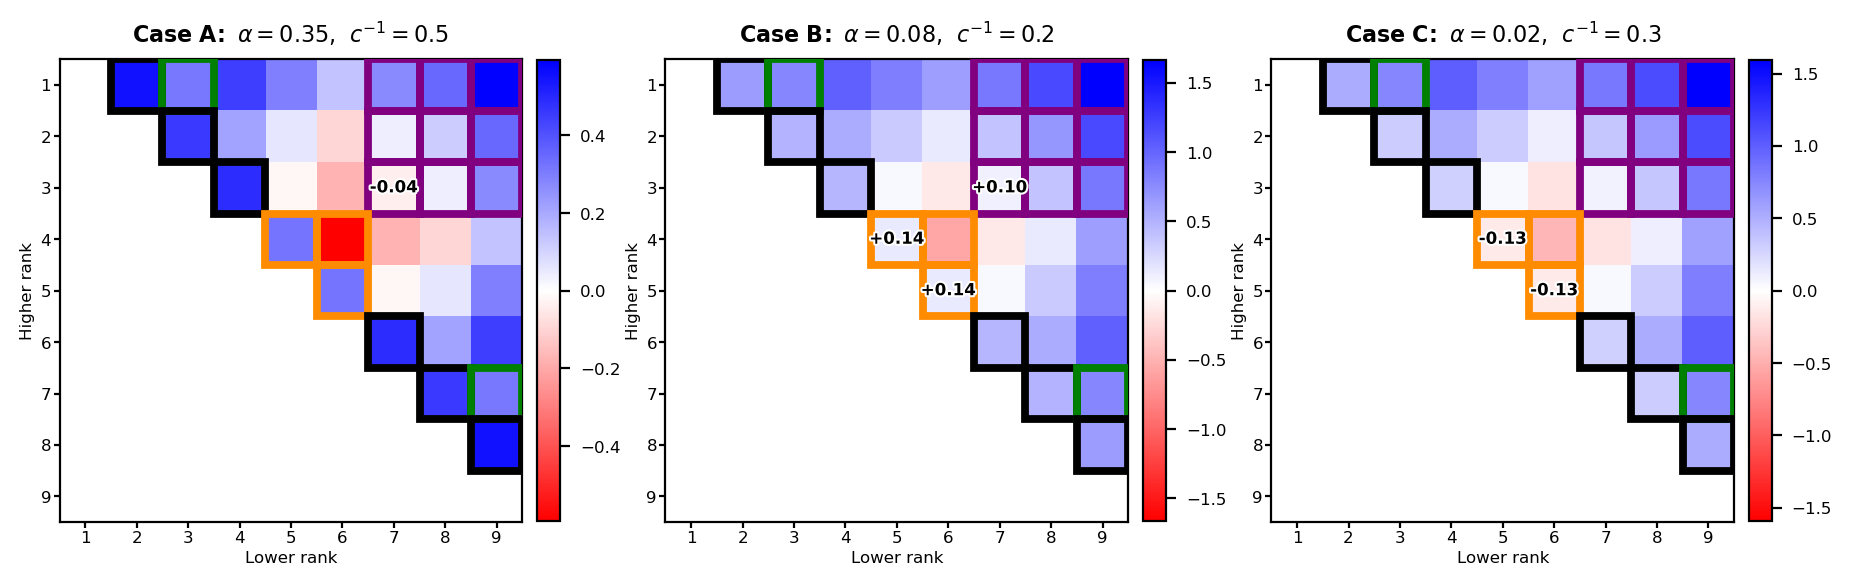

In [4]:
#3 heatmaps
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from Ranking_exp import Ranking_exp


def _build_matrix(sub: pd.DataFrame, metric: str):
    agg = (
        sub.groupby(["rank_higher", "rank_lower", "seed"])[metric].mean()
        .reset_index()
        .groupby(["rank_higher", "rank_lower"])[metric].mean()
        .reset_index()
    )
    meta = (
        sub.groupby(["rank_higher", "rank_lower"])[
            ["is_train", "is_exception", "within_gen", "across_gen"]
        ]
        .first()
        .reset_index()
    )
    agg = agg.merge(meta, on=["rank_higher", "rank_lower"])
    n = int(agg[["rank_higher", "rank_lower"]].max().max()) + 1
    M                = np.full((n, n), np.nan)
    train_mask       = np.zeros((n, n), dtype=bool)
    exc_mask         = np.zeros((n, n), dtype=bool)
    within_gen_mask  = np.zeros((n, n), dtype=bool)
    across_gen_mask  = np.zeros((n, n), dtype=bool)
    for _, row in agg.iterrows():
        i, j = int(row["rank_higher"]), int(row["rank_lower"])
        M[i, j] = row[metric]
        if row["is_train"] and not row["is_exception"]:
            train_mask[i, j] = True
        elif row["is_exception"]:
            exc_mask[i, j] = True
        elif row["within_gen"]:
            within_gen_mask[i, j] = True
        elif row["across_gen"]:
            across_gen_mask[i, j] = True

    # Keep only the diagonal and upper triangle (i <= j); hide the rest.
    lower = np.tril_indices(n, k=-1)
    M[lower]               = np.nan
    train_mask[lower]      = False
    exc_mask[lower]        = False
    within_gen_mask[lower] = False
    across_gen_mask[lower] = False

    return M, train_mask, exc_mask, within_gen_mask, across_gen_mask


def _draw_matrix(ax, M, train_mask, exc_mask, within_gen_mask, across_gen_mask,
                 *, cmap, vmin, vmax, fmt,
                 tick_labels=None, show_numbers=False,
                 annotate_cells=None, colorbar_label=""):
    n = M.shape[0]
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label(colorbar_label, fontsize=6)
    cb.ax.tick_params(labelsize=6)

    if show_numbers:
        for i in range(n):
            for j in range(n):
                if not np.isnan(M[i, j]):
                    ax.text(j, i, f"{M[i, j]:{fmt}}", ha="center", va="center",
                            fontsize=5, color="black")
    elif annotate_cells:
        for (r1, c1) in annotate_cells:
            r0, c0 = r1 - 1, c1 - 1
            if not np.isnan(M[r0, c0]):
                ax.text(c0, r0, f"{M[r0, c0]:{fmt}}", ha="center", va="center",
                        fontsize=6, color="black", fontweight="bold", zorder=4,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground="white")])

    lw    = 2.8
    inset = 0.00
    for i in range(n):
        for j in range(n):
            if train_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="black", lw=lw, zorder=3))
            elif exc_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="darkorange", lw=lw, zorder=3))
            elif within_gen_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5+inset, i-0.5+inset),
                                           1-2*inset, 1-2*inset,
                             fill=False, edgecolor="green", lw=lw, zorder=3))
            elif across_gen_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5+inset, i-0.5+inset),
                                           1-2*inset, 1-2*inset,
                             fill=False, edgecolor="purple", lw=lw, zorder=3))

    labels = tick_labels if tick_labels is not None else [str(k + 1) for k in range(n)]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Lower rank", fontsize=6, labelpad=2)
    ax.set_ylabel("Higher rank", fontsize=6, labelpad=2)
    ax.tick_params(axis="both", length=2, pad=1)


# ── shared experiment parameters ──────────────────────────────────────
n   = 9
p   = 6
q   = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

# Representative conditions from the phase diagram
# (alpha, c_inv) → k_o = (1 - alpha)/2 * delta_s + k_d,  c_reg = 1 / (c_inv * delta_s)
conditions_alpha = [
    (0.35, 0.50),   # Case A
    (0.08, 0.20),   # Case B
    (0.02, 0.30),   # Case C
]
conditions = [((1 - a) / 2 * delta_s + k_d, c_inv) for a, c_inv in conditions_alpha]

# ── build one heatmap-DataFrame per condition ─────────────────────────
def build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d):
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)
    rows = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            margin = sim.f_j_k(i + 1, j + 1)
            transverse_pairs = (
                (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)]
                or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
            )
            is_train = (i == j + 1) or (j == i + 1) #  or transverse_pairs

            # Section membership (0-indexed):
            #   O^(1) = {I_1, ..., I_{q-1}}  ->  indices {0, ..., q-2}
            #   O^(2) = {I_{p+1}, ..., I_n}  ->  indices {p, ..., n-1}
            in_O1_i = i < q - 1
            in_O1_j = j < q - 1
            in_O2_i = i >= p
            in_O2_j = j >= p
            within_gen = (in_O1_i and in_O1_j) or (in_O2_i and in_O2_j)
            across_gen = (in_O1_i and in_O2_j) or (in_O2_i and in_O1_j)

            rows.append({
                "phase":        "post",
                "seed":         0,
                "rank_higher":  i,
                "rank_lower":   j,
                "margin":       margin,
                "correct":      1 if margin > 0 else 0,
                "is_train":     is_train,
                "is_exception": transverse_pairs,
                "within_gen":   within_gen,
                "across_gen":   across_gen,
            })
    return pd.DataFrame(rows)


# ── plot: three columns of margin heatmaps ────────────────────────────
with plt.rc_context({"figure.dpi": 200}):
    fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0))

    # Per-condition margin annotations: 1-indexed (row, col) tuples.
    annotate_cells_map = {
        0: [(3, 7)],
        1: [(3, 7), (4, 5), (5, 6)],
        2: [(4, 5), (5, 6)],
    }

    # Per-condition title prefixes (bolded via mathtext \mathbf).
    title_prefix_map = {
        0: r"$\mathbf{Case\ A\!:}$ ",
        1: r"$\mathbf{Case\ B\!:}$ ",
        2: r"$\mathbf{Case\ C\!:}$ ",
    }

    for idx, ((k_o, c_inv), (alpha_c, _)) in enumerate(zip(conditions, conditions_alpha)):
        c_reg = 1.0 / (c_inv * delta_s)
        df = build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d)
        sub = df[df["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)

        ax = axes[idx]
        _draw_matrix(
            ax, M_m, tm, em, wgm, agm,
            cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
            show_numbers=False,
            annotate_cells=annotate_cells_map.get(idx, []),
            colorbar_label="",
        )
        ax.set_title(
            f"{title_prefix_map.get(idx, '')}$\\alpha={alpha_c:.2f}$,  $c^{{-1}}={c_inv}$",
            fontsize=8, pad=6,
        )

    # fig.suptitle(
    #     f"Figure 4.3a — Representative $f(j,k)$ heatmaps  "
    #     f"(n={n}, p={p}, q={q})",
    #     fontsize=10, y=1.04,
    # )
    plt.tight_layout(pad=0.5, w_pad=0.2)
    plt.show()
    fig.savefig("figure_4_3a.pdf", bbox_inches="tight")

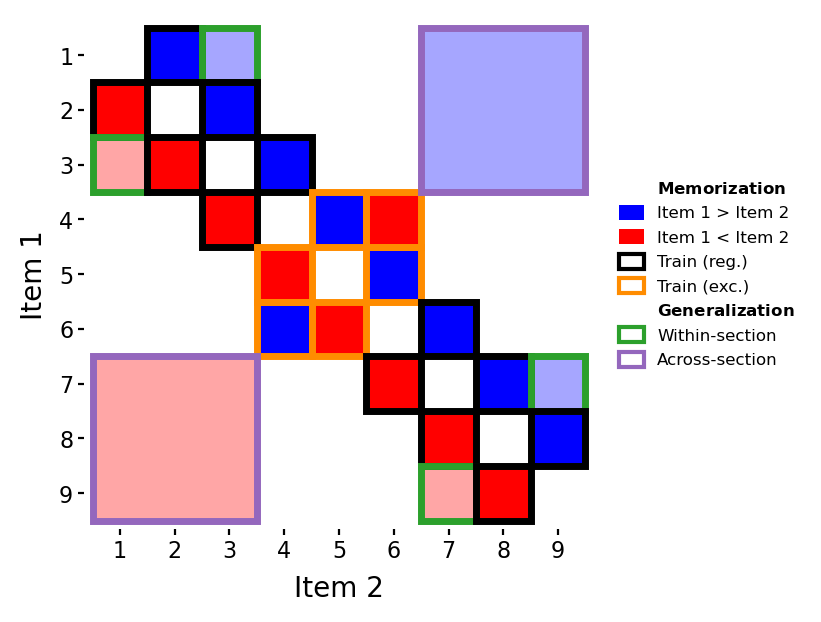

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

# ── Parameters matching the ranking experiment ────────────────────────
items = list("123456789")
n = len(items)
p = 6   # O^(2) starts at index p  (items p+1 .. n)
q = 4   # O^(1) ends at index q-2  (items 1 .. q-1)

# ── Build numeric matrix ─────────────────────────────────────────────
# Blue/red FLIPPED from original cell 1:
#   Upper triangle (j > i) → blue (positive):  dark = train, light = test
#   Lower triangle (j < i) → red  (negative):  dark = train, light = test
M = np.full((n, n), np.nan)
train_mask      = np.zeros((n, n), dtype=bool)
exc_mask        = np.zeros((n, n), dtype=bool)
within_gen_mask = np.zeros((n, n), dtype=bool)
across_gen_mask = np.zeros((n, n), dtype=bool)

for i in range(n):
    for j in range(n):
        if i == j:
            continue

        is_adjacent = abs(i - j) == 1

        # Section membership (0-indexed):
        #   O^(1) = {I_1, ..., I_{q-1}} → indices 0 .. q-2
        #   O^(2) = {I_{p+1}, ..., I_n} → indices p .. n-1
        in_O1_i, in_O1_j = i < q - 1, j < q - 1
        in_O2_i, in_O2_j = i >= p,     j >= p

        # Exception (transverse) pairs – same definition as heatmap cell
        is_exception = (
            (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)]
            or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
        )

        # Only the true transverse pair (items 4,6) gets swapped fill colors
        is_swapped_exception = (i, j) in [(q-1, p-1), (p-1, q-1)]

        within_gen = (in_O1_i and in_O1_j) or (in_O2_i and in_O2_j)
        across_gen = (in_O1_i and in_O2_j) or (in_O2_i and in_O1_j)

        # Numeric values → bwr_r maps positive to blue, negative to red
        # Only swapped-exception pairs get inverted colors; other exceptions
        # follow normal fill (dark if adjacent, light if not)
        # Uncategorized cells stay NaN (blank/white)
        if is_exception or is_adjacent or within_gen or across_gen:
            if j > i:   # upper triangle → normally blue
                if is_swapped_exception:
                    M[i, j] = -1.0   # red in blue territory
                else:
                    M[i, j] = 1.0 if is_adjacent else 0.35
            else:        # lower triangle → normally red
                if is_swapped_exception:
                    M[i, j] = 1.0    # blue in red territory
                else:
                    M[i, j] = -1.0 if is_adjacent else -0.35

        # Highlight masks (exception takes priority over train)
        if is_exception:
            exc_mask[i, j] = True
        elif is_adjacent:
            train_mask[i, j] = True
        elif within_gen:
            within_gen_mask[i, j] = True
        elif across_gen:
            across_gen_mask[i, j] = True

# ── Derive legend colors from the colormap ────────────────────────────
cmap = plt.cm.bwr_r
color_upper_train = cmap(1.0)           # +1.0
color_upper_test  = cmap((0.35 + 1) / 2)  # +0.35 normalised
color_lower_train = cmap(0.0)           # -1.0
color_lower_test  = cmap((-0.35 + 1) / 2) # -0.35 normalised

# ── Plot ──────────────────────────────────────────────────────────────
with plt.rc_context({"figure.dpi": 200}):
    fig, ax = plt.subplots(figsize=(4.2, 4.2))

    ax.imshow(M, cmap="bwr_r", vmin=-1, vmax=1,
              aspect="equal", interpolation="nearest")

    # Border highlights — individual per-cell rectangles for train & exception
    lw = 2.5
    for i in range(n):
        for j in range(n):
            if train_mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor="black", lw=lw, zorder=3))
            elif exc_mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor="darkorange", lw=lw, zorder=3))
            elif within_gen_mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor="tab:green", lw=lw, zorder=3))

    # Across-section: two big block rectangles
    n_O1 = q - 1   # 3 items in O^(1): indices 0..2
    n_O2 = n - p    # 3 items in O^(2): indices 6..8
    ax.add_patch(Rectangle(
        (p - 0.5, -0.5), n_O2, n_O1,
        fill=False, edgecolor="tab:purple", lw=lw, zorder=3))
    ax.add_patch(Rectangle(
        (-0.5, p - 0.5), n_O1, n_O2,
        fill=False, edgecolor="tab:purple", lw=lw, zorder=3))

    # Ensure the big border rectangles aren't clipped
    margin = 0.15
    ax.set_xlim(-0.5 - margin, n - 0.5 + margin)
    ax.set_ylim(n - 0.5 + margin, -0.5 - margin)

    # Compact tick labels & axis labels (cell-2 style)
    labels = [str(k + 1) for k in range(n)]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Item 2", fontsize=6, labelpad=4)
    ax.set_ylabel("Item 1", fontsize=6, labelpad=4)
    ax.tick_params(axis="both", length=2, pad=2)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    def _legend_header(label):
        return Patch(facecolor="none", edgecolor="none", label=label)

    legend_elements = [
        _legend_header(r"$\bf{Memorization}$"),
        Patch(facecolor=color_upper_train, label="Item 1 > Item 2"),
        Patch(facecolor=color_lower_train, label="Item 1 < Item 2"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="black",
                  lw=1.5, label="Train (reg.)"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="darkorange",
                  lw=1.5, label="Train (exc.)"),
        _legend_header(r"$\bf{Generalization}$"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="tab:green",
                  lw=1.5, label="Within-section"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="tab:purple",
                  lw=1.5, label="Across-section"),
    ]
    ax.legend(
        handles=legend_elements, fontsize=6, frameon=False,
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        handlelength=1.5, handleheight=1.0,
    )

    plt.tight_layout()
    plt.show()

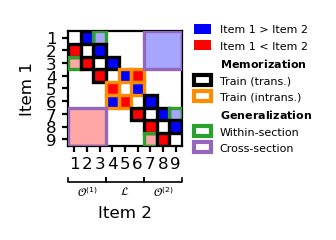

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

# ── Parameters matching the ranking experiment ────────────────────────
items = list("123456789")
n = len(items)
p = 6   # O^(2) starts at index p  (items p+1 .. n)
q = 4   # O^(1) ends at index q-2  (items 1 .. q-1)

# ── Build numeric matrix ─────────────────────────────────────────────
# Blue/red FLIPPED from original cell 1:
#   Upper triangle (j > i) → blue (positive):  dark = train, light = test
#   Lower triangle (j < i) → red  (negative):  dark = train, light = test
M = np.full((n, n), np.nan)
train_mask      = np.zeros((n, n), dtype=bool)
exc_mask        = np.zeros((n, n), dtype=bool)
within_gen_mask = np.zeros((n, n), dtype=bool)
across_gen_mask = np.zeros((n, n), dtype=bool)

for i in range(n):
    for j in range(n):
        if i == j:
            continue

        is_adjacent = abs(i - j) == 1

        # Section membership (0-indexed):
        #   O^(1) = {I_1, ..., I_{q-1}} → indices 0 .. q-2
        #   O^(2) = {I_{p+1}, ..., I_n} → indices p .. n-1
        in_O1_i, in_O1_j = i < q - 1, j < q - 1
        in_O2_i, in_O2_j = i >= p,     j >= p

        # Exception (transverse) pairs – same definition as heatmap cell
        is_exception = (
            (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)]
            or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
        )

        # Only the true transverse pair (items 4,6) gets swapped fill colors
        is_swapped_exception = (i, j) in [(q-1, p-1), (p-1, q-1)]

        within_gen = (in_O1_i and in_O1_j) or (in_O2_i and in_O2_j)
        across_gen = (in_O1_i and in_O2_j) or (in_O2_i and in_O1_j)

        # Numeric values → bwr_r maps positive to blue, negative to red
        # Only swapped-exception pairs get inverted colors; other exceptions
        # follow normal fill (dark if adjacent, light if not)
        # Uncategorized cells stay NaN (blank/white)
        if is_exception or is_adjacent or within_gen or across_gen:
            if j > i:   # upper triangle → normally blue
                if is_swapped_exception:
                    M[i, j] = -1.0   # red in blue territory
                else:
                    M[i, j] = 1.0 if is_adjacent else 0.35
            else:        # lower triangle → normally red
                if is_swapped_exception:
                    M[i, j] = 1.0    # blue in red territory
                else:
                    M[i, j] = -1.0 if is_adjacent else -0.35

        # Highlight masks (exception takes priority over train)
        if is_exception:
            exc_mask[i, j] = True
        elif is_adjacent:
            train_mask[i, j] = True
        elif within_gen:
            within_gen_mask[i, j] = True
        elif across_gen:
            across_gen_mask[i, j] = True

# ── Derive legend colors from the colormap ────────────────────────────
cmap = plt.cm.bwr_r
color_upper_train = cmap(1.0)           # +1.0
color_upper_test  = cmap((0.35 + 1) / 2)  # +0.35 normalised
color_lower_train = cmap(0.0)           # -1.0
color_lower_test  = cmap((-0.35 + 1) / 2) # -0.35 normalised

# ── Plot ──────────────────────────────────────────────────────────────
with plt.rc_context({"figure.dpi": 200}):
    fig, ax = plt.subplots(figsize=(1.8, 4))

    ax.imshow(M, cmap="bwr_r", vmin=-1, vmax=1,
              aspect="equal", interpolation="nearest")

    # Border highlights — individual per-cell rectangles for train & exception
    lw = 1.2
    for i in range(n):
        for j in range(n):
            if train_mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor="black", lw=lw, zorder=3))
            elif exc_mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor="darkorange", lw=lw, zorder=3))
            elif within_gen_mask[i, j]:
                ax.add_patch(Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    fill=False, edgecolor="tab:green", lw=lw, zorder=3))

    # Across-section: two big block rectangles
    n_O1 = q - 1   # 3 items in O^(1): indices 0..2
    n_O2 = n - p    # 3 items in O^(2): indices 6..8
    ax.add_patch(Rectangle(
        (p - 0.5, -0.5), n_O2, n_O1,
        fill=False, edgecolor="tab:purple", lw=lw, zorder=3))
    ax.add_patch(Rectangle(
        (-0.5, p - 0.5), n_O1, n_O2,
        fill=False, edgecolor="tab:purple", lw=lw, zorder=3))

    # Ensure the big border rectangles aren't clipped
    margin = 0
    ax.set_xlim(-0.5 - margin, n - 0.5 + margin)
    ax.set_ylim(n - 0.5 + margin, -0.5 - margin)

    # Compact tick labels & axis labels (cell-2 style)
    labels = [str(k + 1) for k in range(n)]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Item 2", fontsize=6, labelpad=12)
    ax.set_ylabel("Item 1", fontsize=6, labelpad=4)
    ax.tick_params(axis="both", length=2, pad=2)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(0.8)

    def _legend_header(label):
        return Patch(facecolor="none", edgecolor="none", label=label)

    legend_elements = [
        Patch(facecolor=color_upper_train, label="Item 1 > Item 2"),
        Patch(facecolor=color_lower_train, label="Item 1 < Item 2"),
        _legend_header(r"$\bf{Memorization}$"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="black",
                  lw=1.5, label="Train (trans.)"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="darkorange",
                  lw=1.5, label="Train (intrans.)"),
        _legend_header(r"$\bf{Generalization}$"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="tab:green",
                  lw=1.5, label="Within-section"),
        Rectangle((0, 0), 1, 1, fill=False, edgecolor="tab:purple",
                  lw=1.5, label="Cross-section"),
    ]
    ax.legend(
        handles=legend_elements, fontsize=4, frameon=False,
        bbox_to_anchor=(1.02, 0.5), loc="center left",
        handlelength=1.5, handleheight=1.0,
    )

    # ax.set_title("TI with exceptions", fontsize=6, fontweight="bold", pad=20)

    plt.tight_layout()

    # ── Block-structure brackets (O^(1), L, O^(2)) ───────────────────────
    # Spans in data coords: O^(1) = items 1–3, L = 4–6, O^(2) = 7–9
    spans = [
        (-0.5, 2.5, r"$\mathcal{O}^{(1)}$"),
        ( 2.5, 5.5, r"$\mathcal{L}$"),
        ( 5.5, 8.5, r"$\mathcal{O}^{(2)}$"),
    ]
    bk_lw, bk_color = 0.6, "black"

    # Below the x-axis tick labels
    trans_x = ax.get_xaxis_transform()  # x: data, y: axes fraction
    y_top, y_bot, y_lbl = -0.28, -0.32, -0.34
    for x1, x2, lbl in spans:
        ax.plot([x1, x1, x2, x2], [y_top, y_bot, y_bot, y_top],
                transform=trans_x, color=bk_color, lw=bk_lw, clip_on=False)
        ax.text((x1 + x2) / 2, y_lbl, lbl, ha="center", va="top",
                transform=trans_x, fontsize=4)

    # # Left of the y-axis tick labels
    # trans_y = ax.get_yaxis_transform()  # x: axes fraction, y: data
    # x_top, x_bot, x_lbl = -0.22, -0.28, -0.31
    # for y1, y2, lbl in spans:
    #     ax.plot([x_top, x_bot, x_bot, x_top], [y1, y1, y2, y2],
    #             transform=trans_y, color=bk_color, lw=bk_lw, clip_on=False)
    #     ax.text(x_lbl, (y1 + y2) / 2, lbl, ha="right", va="center",
    #             transform=trans_y, fontsize=4, rotation=90)

    plt.savefig("Figure_1.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    